### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics 
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_3813/4013632372.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [2]:
best_model_path = "model/CNN-Best.pkl"
model_path = "model/CNN-Final.pkl"

### Noise Library Loader & Analyzer

In [3]:
class NoiseLibrary:
    """
    Load and analyze all noise samples for augmentation.
    Stores metadata about each noise: length, RMS level, etc.
    """
    def __init__(self, noise_dir='/root/minor/keyboard_sound/model/Noises'):
        self.noise_dir = noise_dir
        self.noises = {
            'city': [],
            'classroom': [],
            'office': [],
            'common': []
        }
        self.noise_metadata = []
        self.load_all_noises()
    
    def load_all_noises(self):
        """Load all noise files and compute their metadata"""
        print("Loading noise library...")
        
        # Define category mapping
        categories = {
            'city': 'city',
            'classroom': 'classroom',
            'office': 'office',
            'Common Noises': 'common'
        }
        
        for category_folder, category_key in categories.items():
            category_path = os.path.join(self.noise_dir, category_folder)
            if not os.path.exists(category_path):
                print(f"Warning: {category_path} not found")
                continue
            
            for filename in os.listdir(category_path):
                if filename.endswith(('.wav', '.mp3', '.flac', '.ogg')):
                    file_path = os.path.join(category_path, filename)
                    try:
                        waveform, sr = torchaudio.load(file_path)
                        
                        # Convert to mono if stereo
                        if waveform.shape[0] > 1:
                            waveform = torch.mean(waveform, dim=0, keepdim=True)
                        
                        # Resample to 16kHz if needed (standard for keystroke audio)
                        if sr != 44100:
                            resampler = torchaudio.transforms.Resample(sr, 44100)
                            waveform = resampler(waveform)
                        
                        # Calculate RMS (Root Mean Square) for noise level
                        rms = torch.sqrt(torch.mean(waveform ** 2)).item()
                        
                        noise_info = {
                            'category': category_key,
                            'waveform': waveform,
                            'length': waveform.shape[1],
                            'rms': rms,
                            'filename': filename
                        }
                        
                        self.noises[category_key].append(noise_info)
                        self.noise_metadata.append(noise_info)
                        
                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")
        
        # Print statistics
        total_noises = len(self.noise_metadata)
        print(f"\n✅ Loaded {total_noises} noise samples:")
        for category, noises in self.noises.items():
            if noises:
                avg_len = np.mean([n['length'] for n in noises])
                avg_rms = np.mean([n['rms'] for n in noises])
                print(f"  - {category}: {len(noises)} samples | Avg length: {avg_len/16000:.2f}s | Avg RMS: {avg_rms:.4f}")
    
    def get_random_noise(self, category=None):
        """Get a random noise sample, optionally from a specific category"""
        if category and self.noises[category]:
            return random.choice(self.noises[category])
        elif self.noise_metadata:
            return random.choice(self.noise_metadata)
        return None
    
    def get_noise_segment(self, target_length, category=None):
        """Get a noise segment of specified length"""
        noise_info = self.get_random_noise(category)
        if noise_info is None:
            return None
        
        waveform = noise_info['waveform']
        noise_length = waveform.shape[1]
        
        if noise_length >= target_length:
            # Random crop
            start = random.randint(0, noise_length - target_length)
            return waveform[:, start:start + target_length]
        else:
            # Loop the noise to match target length
            repeats = (target_length // noise_length) + 1
            waveform = waveform.repeat(1, repeats)
            return waveform[:, :target_length]

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary()
print("✅ Noise Library Ready!\n")

Initializing Noise Library...
Loading noise library...

✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Noise Library Ready!



### SNR-Based Noise Addition Functions

In [4]:
def calculate_rms(waveform):
    """Calculate Root Mean Square (RMS) of waveform"""
    return torch.sqrt(torch.mean(waveform ** 2))

def add_noise_snr(signal, noise, target_snr_db):
    """
    Add noise to signal at a specific SNR (Signal-to-Noise Ratio) level.
    
    Args:
        signal: Clean audio signal (torch.Tensor)
        noise: Noise audio (torch.Tensor)
        target_snr_db: Target SNR in decibels (5-20 dB recommended)
                      5 dB = very noisy, 10 dB = realistic, 20 dB = light noise
    
    Returns:
        Noisy signal with specified SNR
    """
    # Calculate RMS of signal and noise
    signal_rms = calculate_rms(signal)
    noise_rms = calculate_rms(noise)
    
    # Calculate required noise scaling factor
    # SNR = 20 * log10(signal_rms / noise_rms)
    # noise_rms_target = signal_rms / (10 ^ (SNR/20))
    snr_linear = 10 ** (target_snr_db / 20.0)
    target_noise_rms = signal_rms / snr_linear
    
    # Scale noise to achieve target SNR
    scaling_factor = target_noise_rms / (noise_rms + 1e-10)
    scaled_noise = noise * scaling_factor
    
    # Add noise to signal
    noisy_signal = signal + scaled_noise
    
    return noisy_signal

def add_white_noise_snr(signal, target_snr_db):
    """
    Add white (uniform) noise at specified SNR
    
    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB
    
    Returns:
        Signal with white noise
    """
    # Generate white noise with same shape as signal
    noise = torch.randn_like(signal)
    return add_noise_snr(signal, noise, target_snr_db)

def add_gaussian_noise_snr(signal, target_snr_db):
    """
    Add Gaussian noise at specified SNR
    
    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB
    
    Returns:
        Signal with Gaussian noise
    """
    # Generate Gaussian noise
    noise = torch.normal(mean=0, std=0.1, size=signal.shape)
    return add_noise_snr(signal, noise, target_snr_db)

def reduce_volume_db(signal, db_reduction):
    """
    Reduce signal volume by specified dB (simulates microphone placed further away)
    
    Args:
        signal: Audio signal
        db_reduction: dB to reduce (positive value, e.g., 6 dB, 10 dB, 15 dB)
    
    Returns:
        Quieter signal
    """
    # Convert dB to linear scale
    # dB = 20 * log10(amplitude_ratio)
    amplitude_ratio = 10 ** (-db_reduction / 20.0)
    return signal * amplitude_ratio

### Hybrid Noise Augmentation Pipeline

In [5]:
class AggressiveMultiVariationAugmentation:
    """
    AGGRESSIVE multi-variation augmentation for training robustness.
    
    Applies MANY VARIATIONS with both small and large noise:
    - Real ambient noise (all 4 categories)
    - White noise
    - Gaussian noise  
    - Mixed combinations (real+white, real+gaussian)
    - Wide SNR range: 0-30 dB (from very noisy to nearly clean)
    - Volume variations
    - Multiple augmentations per sample
    
    NO CLEAN SAMPLES - Always augment to force model robustness!
    """
    def __init__(self, noise_library, 
                 snr_range=(0, 30),           # Wide range: very noisy (0dB) to clean (30dB)
                 volume_reduction_prob=0.4,   # 40% chance
                 volume_reduction_range=(2, 15),  # 2-15 dB reduction
                 multi_aug_prob=0.3):         # 30% chance of multiple augmentations
        """
        Args:
            noise_library: NoiseLibrary instance with loaded noise samples
            snr_range: (min_snr, max_snr) in dB - WIDE RANGE FOR VARIATION
            volume_reduction_prob: Probability of volume reduction
            volume_reduction_range: (min_db, max_db) reduction range
            multi_aug_prob: Probability of applying multiple augmentations
        """
        self.noise_library = noise_library
        self.snr_range = snr_range
        self.volume_reduction_prob = volume_reduction_prob
        self.volume_reduction_range = volume_reduction_range
        self.multi_aug_prob = multi_aug_prob
        
        # Define augmentation strategies with equal probability
        # NO CLEAN OPTION - always augment!
        self.strategies = [
            'real_city',
            'real_office', 
            'real_classroom',
            'real_common',
            'white',
            'gaussian',
            'mixed_real_white',      # Combination
            'mixed_real_gaussian',   # Combination
            'real_random',           # Random category
        ]
        
        print(f"🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:")
        print(f"  ├─ Strategies: {len(self.strategies)} different noise types")
        print(f"  ├─ SNR range: {snr_range[0]}-{snr_range[1]} dB (WIDE - small to large noise)")
        print(f"  ├─ Volume reduction: {volume_reduction_prob*100:.0f}% chance")
        print(f"  ├─ Volume reduction range: {volume_reduction_range[0]}-{volume_reduction_range[1]} dB")
        print(f"  ├─ Multi-augmentation: {multi_aug_prob*100:.0f}% chance")
        print(f"  └─ Clean samples: 0% (ALWAYS AUGMENTED!)")
    
    def apply_augmentation(self, signal, strategy, snr):
        """Apply a single augmentation strategy"""
        signal_length = signal.shape[1] if signal.dim() > 1 else signal.shape[0]
        
        if strategy == 'real_city':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'city')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
        
        elif strategy == 'real_office':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'office')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
        
        elif strategy == 'real_classroom':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'classroom')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
        
        elif strategy == 'real_common':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'common')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
        
        elif strategy == 'real_random':
            # Random noise category
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
        
        elif strategy == 'white':
            signal = add_white_noise_snr(signal, snr)
        
        elif strategy == 'gaussian':
            signal = add_gaussian_noise_snr(signal, snr)
        
        elif strategy == 'mixed_real_white':
            # Apply real noise first
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            # Then add white noise on top with slightly higher SNR
            signal = add_white_noise_snr(signal, snr + 5)
        
        elif strategy == 'mixed_real_gaussian':
            # Apply real noise first
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            # Then add gaussian noise on top with slightly higher SNR
            signal = add_gaussian_noise_snr(signal, snr + 5)
        
        return signal
    
    def __call__(self, signal):
        """
        Apply aggressive multi-variation augmentation to signal
        
        Args:
            signal: Clean audio waveform (torch.Tensor)
        
        Returns:
            Heavily augmented audio waveform
        """
        # Always clone to avoid modifying original
        signal = signal.clone()
        
        # Random SNR across WIDE range (0-30 dB)
        # This gives both very noisy (0-5dB) and fairly clean (25-30dB) samples
        target_snr = random.uniform(self.snr_range[0], self.snr_range[1])
        
        # Randomly select strategy
        strategy = random.choice(self.strategies)
        
        # Apply primary augmentation
        signal = self.apply_augmentation(signal, strategy, target_snr)
        
        # 30% chance to apply a SECOND augmentation for extra variation
        if random.random() < self.multi_aug_prob:
            # Use different SNR for second augmentation
            second_snr = random.uniform(max(target_snr, 10), 30)  # Higher SNR for second layer
            second_strategy = random.choice(['white', 'gaussian'])  # Add synthetic noise
            signal = self.apply_augmentation(signal, second_strategy, second_snr)
        
        # Volume reduction (simulate distant microphone)
        if random.random() < self.volume_reduction_prob:
            db_reduction = random.uniform(
                self.volume_reduction_range[0],
                self.volume_reduction_range[1]
            )
            signal = reduce_volume_db(signal, db_reduction)
        
        return signal

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(-5, 30),              # WIDE: -5dB (very noisy) to 30dB (clean)
    volume_reduction_prob=0.4,      # 40% chance
    volume_reduction_range=(2, 15), # 2-15 dB reduction
    multi_aug_prob=0.3              # 30% double augmentation
)
print("="*70)
print()
print("💪 Training will be HARD on the model with:")
print("  • 9 different noise strategies (4 real categories + synthetics + mixed)")
print("  • SNR from -5dB (very noisy) to 30dB (nearly clean)")
print("  • 40% samples with volume reduction (2-15dB)")
print("  • 30% samples with MULTIPLE augmentations stacked")
print("  • 0% clean samples - ALWAYS augmented!")
print("  • Result: Maximum variation and robustness training")
print("="*70 + "\n")


🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING
🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:
  ├─ Strategies: 9 different noise types
  ├─ SNR range: -5-30 dB (WIDE - small to large noise)
  ├─ Volume reduction: 40% chance
  ├─ Volume reduction range: 2-15 dB
  ├─ Multi-augmentation: 30% chance
  └─ Clean samples: 0% (ALWAYS AUGMENTED!)

💪 Training will be HARD on the model with:
  • 9 different noise strategies (4 real categories + synthetics + mixed)
  • SNR from -5dB (very noisy) to 30dB (nearly clean)
  • 40% samples with volume reduction (2-15dB)
  • 30% samples with MULTIPLE augmentations stacked
  • 0% clean samples - ALWAYS augmented!
  • Result: Maximum variation and robustness training



### Loading data

In [30]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)
                
                # Map digits 0-9 to 0-9, letters a-z to 10-35
                if '0' <= label <= '9':
                    label_index = ord(label) - ord('0')
                elif 'a' <= label <= 'z':
                    label_index = ord(label) - ord('a') + 10  # Map a-z to 10-35
                else:
                    raise ValueError(f"Unexpected label: {label}")
                
                label_tensor = torch.tensor(label_index)
                
                self.labels.add(label_tensor.item())
                
                waveform, sample_rate = torchaudio.load(file_path)
                if self.transform is not None:
                    waveform_transformed = self.transform(waveform)
                else:
                    waveform_transformed = waveform
                
                if waveform_transformed.shape[2] != 64:
                    print("Wrong shape:", waveform_transformed.shape)
                    continue
                
                self.n_samples += 1
                self.dataset.append((waveform_transformed, label_tensor))  # Changed here

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        return waveform, label

    def num_classes(self):
        return len(self.labels)

In [44]:
sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset('recordings/segmented/large', transforms)
print("number of classes:", dataset.num_classes())

number of classes: 36


In [45]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)), 
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices, 
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 20405, Validation set size: 5859, Test set size: 2886


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [46]:
class TrainingDataset(Dataset):
    def __init__(self, base_dataset, transformations):
        super(TrainingDataset, self).__init__()
        self.base = base_dataset
        self.transformations = transformations

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        waveform, label = self.base[idx]
        return self.transformations(waveform), label

In [47]:
class TimeShifting:
    """Time shifting augmentation with increased shift range for better robustness"""
    def __init__(self, shift_ratio=0.5):
        """
        Args:
            shift_ratio: Ratio of audio length to use as max shift (default 0.5 = 50%)
                        Increased from 0.3 to 0.5 for better temporal variation
        """
        self.shift_ratio = shift_ratio
    
    def __call__(self, samples):
        if isinstance(samples, torch.Tensor):
            samples = samples.numpy()
        
        # Increased shift range from 30% to 50% for better augmentation
        shift = int(samples.shape[1] * self.shift_ratio)
        random_shift = random.randint(0, shift)
        
        data_roll = np.zeros_like(samples)
        for ch in range(samples.shape[0]):
            data_roll[ch] = np.roll(samples[ch], random_shift)
        
        return torch.tensor(data_roll)

In [48]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.5),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor
    # HEAVY spectrogram masking for additional robustness
    FrequencyMasking(10),            # Increased from 7 to 10
    TimeMasking(10),                 # Increased from 7 to 10
    FrequencyMasking(10),            # Second pass
    TimeMasking(10),                 # Second pass
    FrequencyMasking(5),             # Third pass (lighter)
    TimeMasking(5),                  # Third pass (lighter)
])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")


✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 20405 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 20405 samples
  ├─ Validation (no augmentation): 5859 samples
  └─ Test (no augmentation): 2886 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [49]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 34
   Waveform shape: torch.Size([1, 64, 64])
   Sample rate: 44100 Hz
   Duration: 0.001 seconds
   RMS: 12.099919

1️⃣  ORIGINAL CLEAN AUDIO


In [50]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 6.064324


   🔉 -12 dB reduction - RMS: 3.039362


In [51]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 12.737588


   🔊 Heavy noise (5 dB SNR) - RMS: 13.827911


In [52]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 12.727990


   🔊 Heavy noise (5 dB SNR) - RMS: 13.755982


In [53]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
real_noise_10db = add_noise_snr(
    test_waveform, 
    noise_library.get_noise_segment(test_waveform.shape[1]), 
    target_snr_db=10
)
real_noise_5db = add_noise_snr(
    test_waveform, 
    noise_library.get_noise_segment(test_waveform.shape[1]), 
    target_snr_db=5
)

# Convert to numpy
real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

# Save
real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
sf.write(real_10db_path, real_10db_audio, sample_rate)
sf.write(real_5db_path, real_5db_audio, sample_rate)

print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
display(Audio(real_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 13.253942


   🔊 Heavy noise (5 dB SNR) - RMS: 16.932690


### Visualization

RuntimeError: Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (1024, 1024) at dimension 2 of input [1, 64, 64]

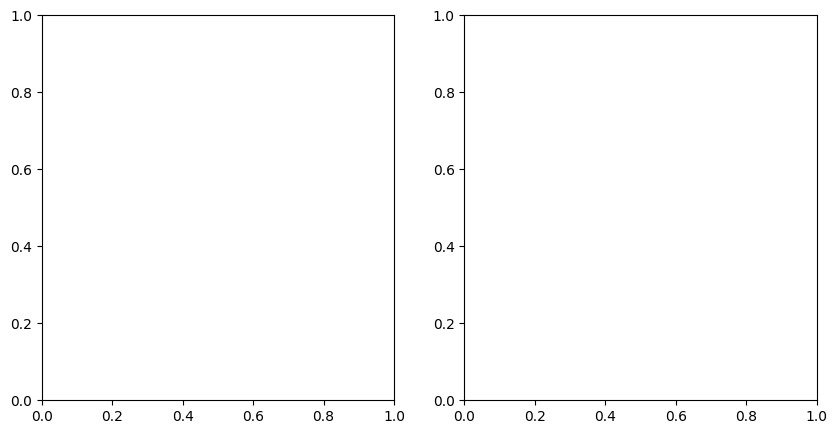

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[0][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [55]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [56]:
class CNN(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()
        
        # Block 1: Conv2D 1->64
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)
        
        # Block 2: Conv2D 64->128
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)
        
        # Block 3: Conv2D 128->256
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.25)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Dense layers
        self.fc1 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Global pooling and flatten
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout4(x)
        
        x = self.fc2(x)
        
        return x

In [57]:
model = CNN(num_classes=dataset.num_classes())

In [58]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [59]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))

Number of parameters: 408,356
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 36]                   --
├─Conv2d: 1-1                            [1, 64, 64, 64]           640
├─BatchNorm2d: 1-2                       [1, 64, 64, 64]           128
├─MaxPool2d: 1-3                         [1, 64, 32, 32]           --
├─Dropout2d: 1-4                         [1, 64, 32, 32]           --
├─Conv2d: 1-5                            [1, 128, 32, 32]          73,856
├─BatchNorm2d: 1-6                       [1, 128, 32, 32]          256
├─MaxPool2d: 1-7                         [1, 128, 16, 16]          --
├─Dropout2d: 1-8                         [1, 128, 16, 16]          --
├─Conv2d: 1-9                            [1, 256, 16, 16]          295,168
├─BatchNorm2d: 1-10                      [1, 256, 16, 16]          512
├─MaxPool2d: 1-11                        [1, 256, 8, 8]            --
├─Dropout2d: 1-12                        [1, 256, 8, 8]            --
├─

### Training setup

In [60]:
train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

In [61]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
num_epochs = 1200

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [62]:
def plot_results(train_losses, train_accuracies, val_losses, val_accuracies):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")
    plt.subplot(1,2,2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    plt.legend(["Training accuracy", "Validation accuracy"], loc="best")
    plt.show()

In [63]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

In [64]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    
    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()
    
    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        val_loss = 0
        
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)
            
            loss = cost(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
    
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")

RuntimeError: Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (1024, 1024) at dimension 2 of input [1, 64, 64]

In [ ]:
save_model(model, model_path)

In [ ]:
print("Best validation acc:", max(val_accuracies))
print("Last validation acc:", val_accuracies[-1])

Best validation acc: 0.9894459102902374
Last validation acc: 0.9875612514134942


### Results

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout2d(p=0.25, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=256, out_feature

In [ ]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [ ]:
predictions_path = 'predictions-cnn.csv'

def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0
    
    model.eval()
    
    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
      
        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels], 
        "true_labels": [label_dict[label] for label in original_labels]
    })
    prediction_df.to_csv(predictions_path)

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)
    
    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))
    
    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [ ]:
cm = predict(test_dataloader)

Test Accuracy: 0.9846977811782709


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021

0.9846977811782709
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        75
           1       1.00      1.00      1.00        72
           2       1.00      0.99      0.99        71
           3       0.99      0.99      0.99        78
           4       0.99      0.99      0.99        72
           5       0.96      0.96      0.96        78
           6       0.99      1.00      0.99        76
           7       0.97      1.00      0.99        76
           8       0.97      0.96      0.97        72
           9       0.99      0.99      0.99        70
          10       0.97      0.95      0.96        39
          11       0.95      1.00      0.97        35
          12       1.00      1.00      1.00        37
          13       1.00      0.97      0.98        33
          14       0.97      1.00      0.99        38
          15       1.00      1.00      1.00        36
          16       1.00      1.00      1.00        35
        

### Confusion matrix

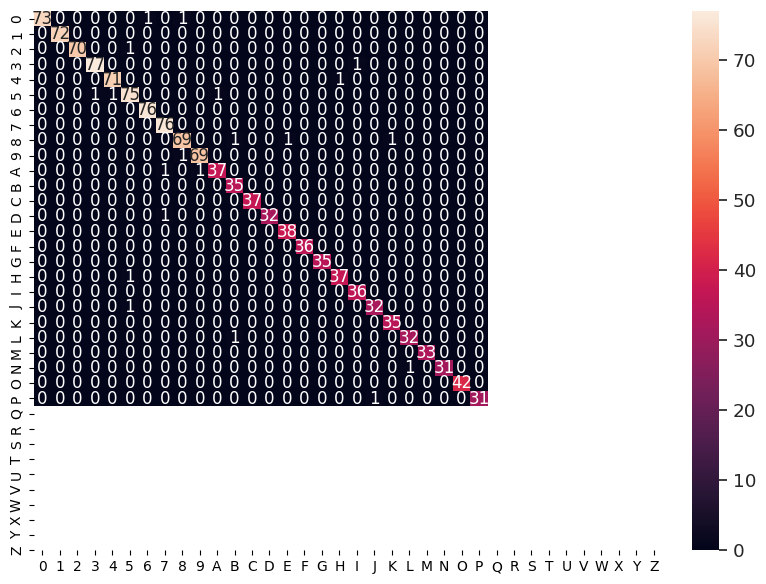

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters, 
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
fig.savefig("confusion_matrix_CNN.pdf", format='pdf', bbox_inches='tight')